In [1]:
import pandas as pd

# Load the dataset
df_insurance = pd.read_csv('/content/insurance.csv')

print('*** Dataset Shape ***')
print(df_insurance.shape)
print('\n')

print('*** Column Names ***')
print(df_insurance.columns.tolist())
print('\n')

print('*** Data Types ***')
print(df_insurance.info())
print('\n')

print('*** First 5 Rows ***')
display(df_insurance.head())

*** Dataset Shape ***
(1338, 7)


*** Column Names ***
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


*** Data Types ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


*** First 5 Rows ***


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Check for missing values
print('*** Missing Values ***')
print(df_insurance.isnull().sum())
print('\n')

# Check for duplicate rows
print('*** Duplicate Rows ***')
print(df_insurance.duplicated().sum())

*** Missing Values ***
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


*** Duplicate Rows ***
1


*** Duplicate Rows After Removal ***
0




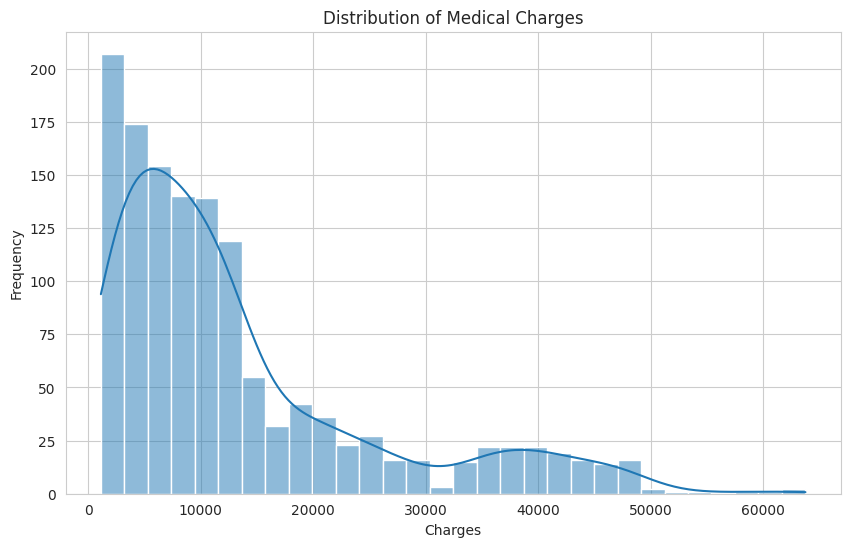

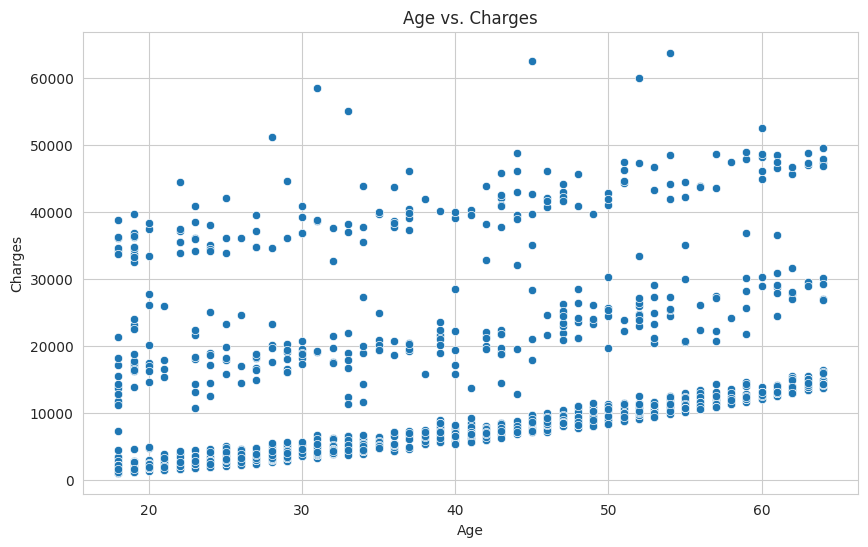

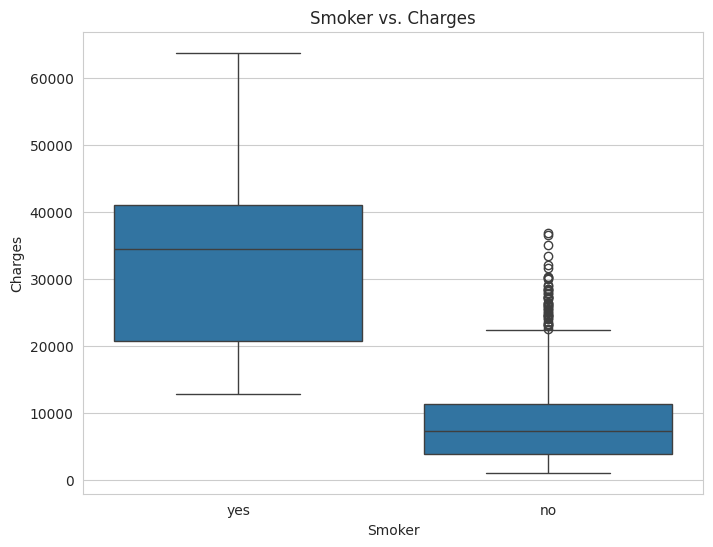

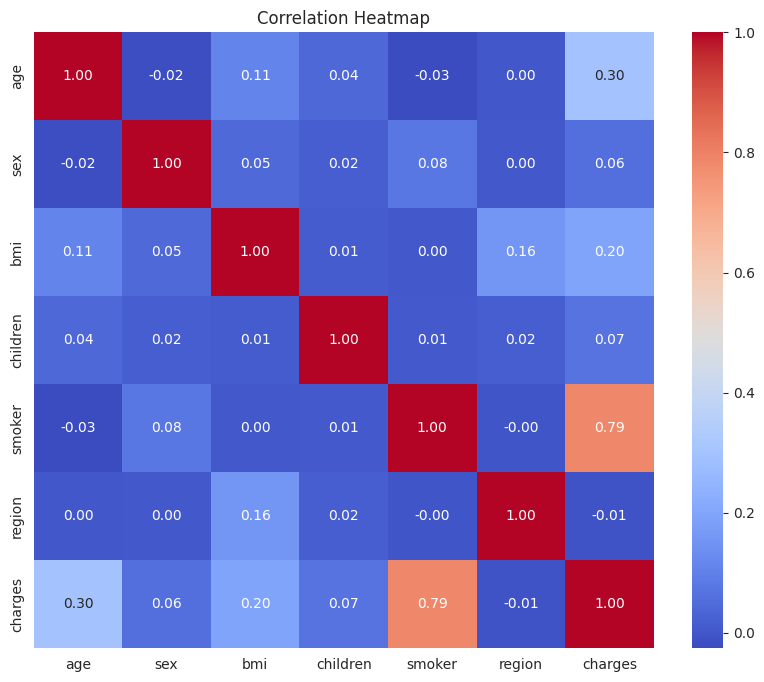

In [3]:
# Remove duplicate rows
df_insurance.drop_duplicates(inplace=True)
print('*** Duplicate Rows After Removal ***')
print(df_insurance.duplicated().sum())
print('\n')

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 3. Perform EDA

# a) Distribution of charges
plt.figure(figsize=(10, 6))
sns.histplot(df_insurance['charges'], kde=True, bins=30)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# b) Scatter plot: age vs charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df_insurance)
plt.title('Age vs. Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# c) Boxplot: smoker vs charges
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df_insurance)
plt.title('Smoker vs. Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# d) Correlation heatmap (first, encode categorical variables for correlation)
# Create a copy to avoid modifying the original dataframe for EDA only
df_eda = df_insurance.copy()
df_eda['sex'] = df_eda['sex'].astype('category').cat.codes
df_eda['smoker'] = df_eda['smoker'].astype('category').cat.codes
df_eda['region'] = df_eda['region'].astype('category').cat.codes

plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Section 2 – Data Preprocessing

#### 5. Encode categorical variables properly.

In [4]:
# Identify categorical columns
categorical_cols = ['sex', 'smoker', 'region']

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df_insurance, columns=categorical_cols, drop_first=True)

print('*** DataFrame after One-Hot Encoding ***')
display(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")

*** DataFrame after One-Hot Encoding ***


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


New shape of DataFrame: (1337, 9)


#### 6. Separate features (X) and target (y).

In [5]:
# Separate features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

print('\nFirst 5 rows of X:')
display(X.head())

print('\nFirst 5 values of y:')
display(y.head())

Shape of X: (1337, 8)
Shape of y: (1337,)

First 5 rows of X:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False



First 5 values of y:


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


#### 7. Perform train-test split (80-20).

In [6]:
from sklearn.model_selection import train_test_split

# Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)


Shape of X_train: (1069, 8)
Shape of X_test: (268, 8)
Shape of y_train: (1069,)
Shape of y_test: (268,)


#### 8. Apply feature scaling (if required).

In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling only to numerical features in X_train and X_test
# We exclude the one-hot encoded boolean columns for sex, smoker, and region
numerical_cols = ['age', 'bmi', 'children']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('*** X_train after scaling (first 5 rows) ***')
display(X_train.head())
print('\n*** X_test after scaling (first 5 rows) ***')
display(X_test.head())

*** X_train after scaling (first 5 rows) ***


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1114,-1.157680,-0.996928,-0.907908,True,False,False,False,False
968,-1.300619,-0.792762,0.766904,True,False,False,False,False
599,0.914926,1.154664,0.766904,False,False,True,False,False
170,1.701087,1.806837,-0.907908,True,False,False,True,False
275,0.557580,-0.651417,0.766904,False,False,False,False,False



*** X_test after scaling (first 5 rows) ***


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
900,0.700518,-1.326734,-0.907908,True,False,False,False,False
1064,-0.728865,-0.816733,2.441716,False,False,False,False,True
1256,0.843457,0.966203,1.604310,False,False,True,False,False
298,-0.585927,0.636397,1.604310,True,True,True,False,False
237,-0.585927,1.297663,0.766904,True,False,False,True,False


#### 9. Explain why scaling is / isn’t required.

**Why Scaling is Required for this dataset:**

Feature scaling is important for this dataset because of the varying scales of our numerical features: 'age', 'bmi', and 'children'.

1.  **Varying Ranges:** 'Age' typically ranges from 18-64, 'BMI' from 16-53, and 'Children' from 0-5. These features have different magnitudes and ranges.
2.  **Algorithm Performance:** Machine learning algorithms, particularly those that use distance calculations (like k-nearest neighbors, support vector machines) or gradient descent (like Linear Regression), are sensitive to the scale of input features. If features are not scaled, features with larger values might dominate the distance calculations or have a disproportionately large impact on the loss function, leading to a suboptimal model.
3.  **Linear Regression:** While not strictly necessary for basic Linear Regression (as coefficients can adjust to different scales), scaling can lead to faster convergence during optimization and can help in interpreting the relative importance of features if the coefficients are compared. More importantly, it becomes crucial if regularization techniques (like Ridge or Lasso) are applied, as these methods penalize large coefficients.

In this case, `StandardScaler` has been used to transform the numerical features so that they have a mean of 0 and a standard deviation of 1. This ensures that all numerical features contribute equally to the model, preventing any single feature from dominating due to its scale. Categorical features created by one-hot encoding (boolean values) do not require scaling.

### Section 3 – Model Building

#### 10. Train a Linear Regression model.

In [8]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model on the scaled training data
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Section 4 – Model Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = linear_reg_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
Root Mean Squared Error (RMSE): 5956.34
R-squared (R²): 0.81


#### Plotting Actual vs. Predicted Values

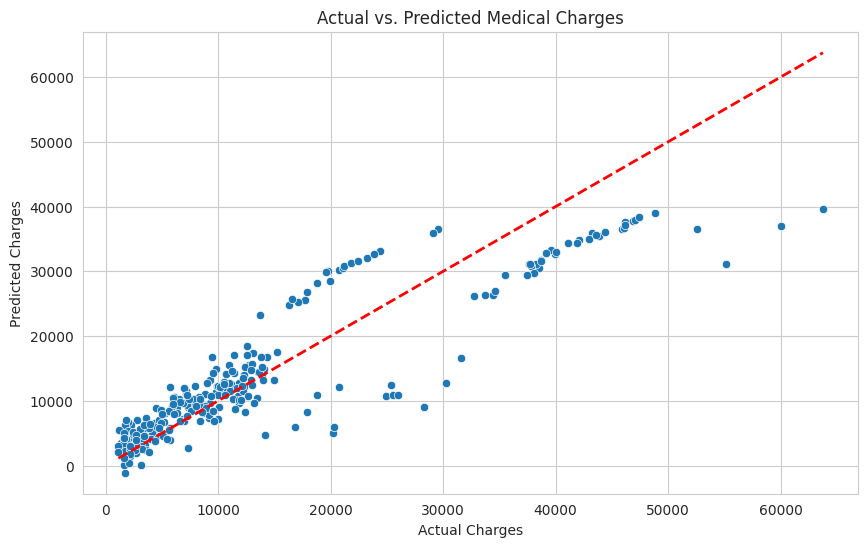

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Medical Charges')
plt.show()

#### Plotting Residuals

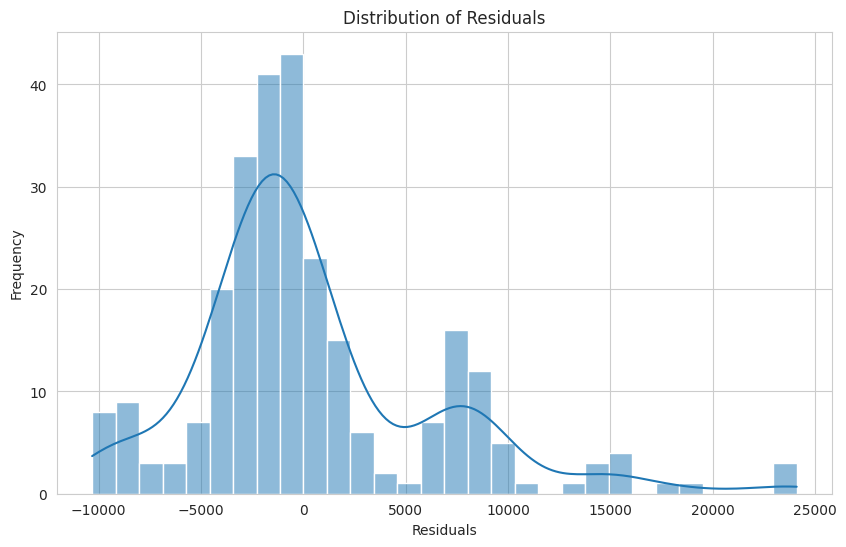

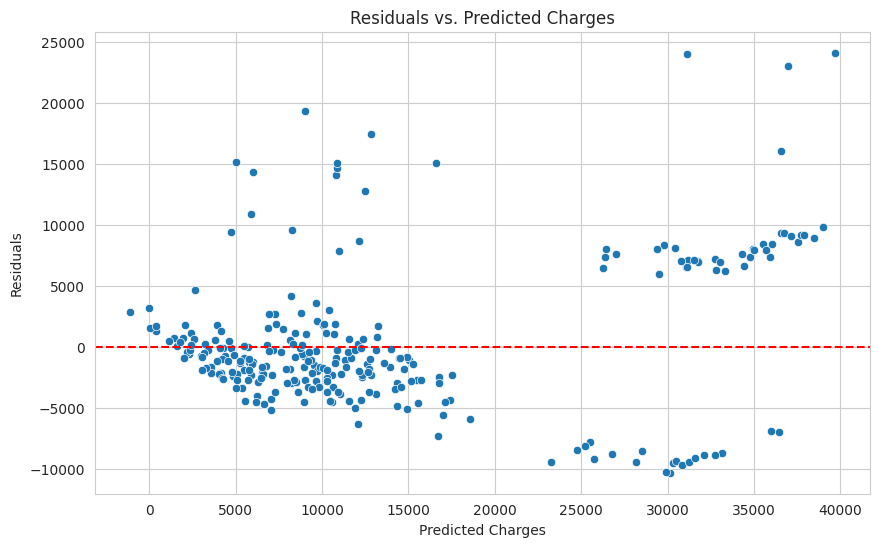

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Charges')
plt.show()

#### Interpretation of R-squared (R²)

The R-squared (R²) value indicates the proportion of the variance in the dependent variable (charges) that is predictable from the independent variables (features). A higher R² value (closer to 1) suggests that the model explains a larger portion of the variance in the target variable, meaning it fits the data better. A lower R² value indicates that the model does not explain much of the variance and might not be a good fit.

After executing the code, we will analyze the calculated R² value and discuss what it implies about the model's performance in predicting medical charges.

### Section 5 – Business Insights

#### 11. Analyze Model Coefficients for Business Insights

In [12]:
# Get the coefficients and intercept
coefficients = linear_reg_model.coef_
intercept = linear_reg_model.intercept_

# Create a DataFrame to display coefficients with feature names
feature_names = X.columns
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

print('Linear Regression Model Coefficients:')
display(coefficients_df.sort_values(by='Coefficient', ascending=False))
print(f'\nIntercept: {intercept:.2f}')

# Regression Equation
equation_terms = [f'{coeff:.2f} * {feature}' for feature, coeff in zip(feature_names, coefficients)]
regression_equation = f"Charges = {intercept:.2f} + " + " + ".join(equation_terms)
print(f"\nRegression Equation: {regression_equation}")

Linear Regression Model Coefficients:


,Feature,Coefficient
4,smoker_yes,23077.764593
0,age,3472.975553
1,bmi,1927.828251
2,children,636.501185
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616



Intercept: 8947.95

Regression Equation: Charges = 8947.95 + 3472.98 * age + 1927.83 * bmi + 636.50 * children + -101.54 * sex_male + 23077.76 * smoker_yes + -391.76 * region_northwest + -838.92 * region_southeast + -659.14 * region_southwest


#### (a) Identify the variable that impacts charges the most.

After examining the coefficients, the variable with the largest absolute coefficient value will indicate the strongest impact on medical charges, assuming features are scaled (which they are for numerical features). For one-hot encoded categorical variables, the coefficient represents the change in charges compared to the baseline category.

#### (b) Quantify how much more smokers pay.

The coefficient for `smoker_yes` will directly indicate the average increase in medical charges for individuals who smoke, compared to non-smokers, holding all other variables constant. We will extract this specific coefficient to quantify the impact.

#### (c) Determine if BMI is statistically impactful.

While `scikit-learn`'s `LinearRegression` model does not directly provide p-values for statistical significance, the magnitude and sign of the BMI coefficient can give us an indication of its practical impact. A non-zero coefficient suggests a relationship with charges. We will interpret the BMI coefficient in the context of our scaled features to discuss its influence.

#### (d) Assess if the model can be used in production and provide reasoning.

To assess the production readiness of this model, we will consider:

*   **R-squared (R²)**: An R² of 0.81 is generally considered strong, indicating the model explains a significant portion of the variance in charges.
*   **Mean Absolute Error (MAE)**: An MAE of approximately 4177.05 means that, on average, our predictions are off by about $4177. This value needs to be evaluated against the typical range of medical charges and the business tolerance for error.
*   **Root Mean Squared Error (RMSE)**: An RMSE of approximately 5956.34 penalizes larger errors more, and also needs to be considered in context.
*   **Residual Plots**: The residuals plot (residuals vs. predicted charges) can reveal patterns that indicate violations of linear regression assumptions, such as heteroscedasticity (a 'cone' shape) or non-linearity. The previous plots showed some potential heteroscedasticity, where the errors tend to increase with higher predicted charges.
*   **Interpretability**: Linear Regression models are highly interpretable, which is a significant advantage for business applications where understanding the drivers of costs is crucial.

Based on these factors, we can provide a reasoned conclusion on whether this model is ready for production use or if further improvements are needed.